In [1]:
import pandas as pd 

df = pd.read_csv("music tours.csv")

print("=Data Shape=")
print("Jumlah Baris dan Kolom:", df.shape)

print("\n=Nama Kolom=")
print(df.columns)

print("\n=Info Dataset=")
print(df.info())

print("\n=Statistik Deskriptif=")
print(df.describe())

#Dataset memiliki X baris dan Y kolom.
#Terdiri dari variabel kategorikal (Artist, City, Genre, dll) dan numerik (Revenue, Attendance, dll).
#Beberapa kolom numerik perlu dipastikan bertipe integer/float.
#Dataset digunakan untuk menganalisis performa tur musik berdasarkan kota, artis, dan pendapatan.

=Data Shape=
Jumlah Baris dan Kolom: (20, 11)

=Nama Kolom=
Index(['Rank', 'Peak', 'All Time Peak', 'Actual gross',
       'Adjusted gross (in 2022 dollars)', 'Artist', 'Tour title', 'Year(s)',
       'Shows', 'Average gross', 'Ref.'],
      dtype='object')

=Info Dataset=
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Rank                              20 non-null     int64 
 1   Peak                              9 non-null      object
 2   All Time Peak                     6 non-null      object
 3   Actual gross                      20 non-null     object
 4   Adjusted gross (in 2022 dollars)  20 non-null     object
 5   Artist                            20 non-null     object
 6   Tour title                        20 non-null     object
 7   Year(s)                           20 non-null     object
 8 

In [2]:
print(df)

    Rank   Peak All Time Peak     Actual gross  \
0      1      1             2     $780,000,000   
1      2      1          7[2]     $579,800,000   
2      3   1[4]          2[5]     $411,000,000   
3      4   2[7]         10[7]     $397,300,000   
4      5   2[4]           NaN     $345,675,146   
5      6   2[4]         10[9]     $305,158,363   
6      7  2[10]           NaN     $280,000,000   
7      7    NaN           NaN     $257,600,000   
8      9    NaN           NaN     $256,084,556   
9     10    NaN           NaN     $250,400,000   
10    11    NaN           NaN  $229,100,000[b]   
11    12    NaN        14[17]     $227,400,000   
12    13    NaN           NaN     $204,000,000   
13    14  1[20]           NaN     $200,000,000   
14    15   2[c]           NaN     $194,000,000   
15    16    NaN           NaN     $184,000,000   
16    17    NaN           NaN     $170,000,000   
17    18    NaN           NaN     $169,800,000   
18    19    NaN           NaN  $167,700,000[e]   


In [3]:
df.columns = df.columns.str.replace('\xa0', ' ')
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Rank', 'Peak', 'All Time Peak', 'Actual gross',
       'Adjusted gross (in 2022 dollars)', 'Artist', 'Tour title', 'Year(s)',
       'Shows', 'Average gross', 'Ref.'],
      dtype='object')


In [4]:
cols_money = ['Actual gross', 'Adjusted gross (in 2022 dollars)', 'Average gross']

for col in cols_money:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('[^0-9.]', '', regex=True)
        .astype(float)
    )

df['Shows'] = pd.to_numeric(df['Shows'], errors='coerce')
df = df.drop(columns=['Ref.'])
print(df)
    

    Rank   Peak All Time Peak  Actual gross  Adjusted gross (in 2022 dollars)  \
0      1      1             2   780000000.0                       780000000.0   
1      2      1          7[2]   579800000.0                       579800000.0   
2      3   1[4]          2[5]   411000000.0                       560622615.0   
3      4   2[7]         10[7]   397300000.0                       454751555.0   
4      5   2[4]           NaN   345675146.0                       402844849.0   
5      6   2[4]         10[9]   305158363.0                       388978496.0   
6      7  2[10]           NaN   280000000.0                       381932682.0   
7      7    NaN           NaN   257600000.0                       257600000.0   
8      9    NaN           NaN   256084556.0                       312258401.0   
9     10    NaN           NaN   250400000.0                       309141878.0   
10    11    NaN           NaN   229100000.0                       283202896.0   
11    12    NaN        14[17

In [5]:
#1.Artis mana dengan pendapatan tertinggi?
df.sort_values(by='Actual gross', ascending=False)[['Artist','Actual gross']].head(3)

,Artist,Actual gross
0,Taylor Swift,780000000.0
1,Beyoncé,579800000.0
2,Madonna,411000000.0


In [6]:
#2.Artis mana paling sering masuk daftar?
df['Artist'].value_counts()

Artist
Taylor Swift    4
Madonna         4
Beyoncé         3
Pink            3
Lady Gaga       2
Celine Dion     1
Katy Perry      1
Cher            1
Adele           1
Name: count, dtype: int64

In [7]:
#3.Bagaimana tren pendapatan tur berdasarkan tahun?
# Ambil 4 digit pertama sebagai tahun awal
df['Start Year'] = df['Year(s)'].str[:4]

# Ubah ke numeric
df['Start Year'] = pd.to_numeric(df['Start Year'], errors='coerce')

df[['Year(s)','Start Year']].head()
trend = df.groupby('Start Year')['Actual gross'].sum()

print(trend)

Start Year
2002    2.000000e+08
2006    1.940000e+08
2008    6.910000e+08
2009    2.274000e+08
2012    4.751584e+08
2013    5.631000e+08
2014    2.040000e+08
2015    4.202000e+08
2016    4.237846e+08
2018    7.429751e+08
2023    1.617400e+09
Name: Actual gross, dtype: float64


In [8]:
#4.Bagaimana tren pendapatan tur berdasarkan tahun?
df.sort_values(by='Average gross', ascending=False)[['Tour title','Average gross']].head(3)

,Tour title,Average gross
0,The Eras Tour †,13928571.0
1,Renaissance World Tour,10353571.0
4,Reputation Stadium Tour,6522173.0


In [9]:
#5.Tahun mana paling dominan?
df['Year(s)'].value_counts()

Year(s)
2013–2014    3
2023–2024    2
2008–2009    2
2023         1
2018–2019    1
2018         1
2012         1
2016         1
2015         1
2009–2011    1
2014–2015    1
2002–2005    1
2006         1
2012–2013    1
2015–2016    1
2016–2017    1
Name: count, dtype: int64

In [10]:
df[['Actual gross','Shows','Average gross']].describe() 

,Actual gross,Shows,Average gross
count,2.000000e+01,20.000000,2.000000e+01
mean,2.879509e+08,110.000000,3.726571e+06
std,1.563284e+08,66.507617,3.393340e+06
min,1.500000e+08,41.000000,6.153850e+05
25%,1.915000e+08,59.000000,1.647508e+06
50%,2.397500e+08,87.000000,2.342100e+06
75%,3.152876e+08,134.500000,4.933024e+06
max,7.800000e+08,325.000000,1.392857e+07


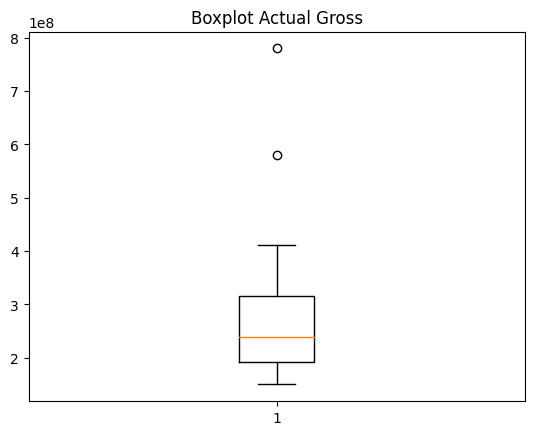

In [11]:
import matplotlib.pyplot as plt

plt.boxplot(df['Actual gross'])
plt.title("Boxplot Actual Gross")
plt.show()

In [12]:
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df['Actual gross']))
print("Outlier Index:", np.where(z > 3))

Outlier Index: (array([0], dtype=int64),)


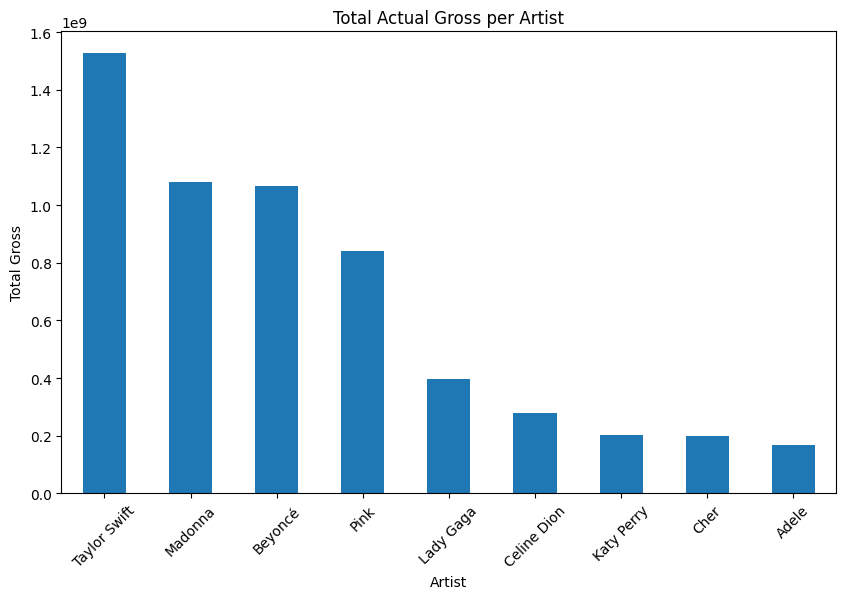

In [13]:
import matplotlib.pyplot as plt

artist_revenue = df.groupby('Artist')['Actual gross'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
artist_revenue.plot(kind='bar')

plt.title("Total Actual Gross per Artist")
plt.xlabel("Artist")
plt.ylabel("Total Gross")
plt.xticks(rotation=45)
plt.show()

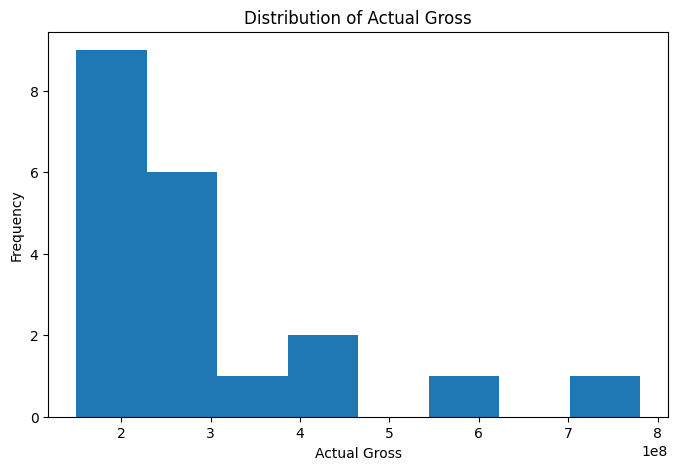

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Actual gross'], bins=8)

plt.title("Distribution of Actual Gross")
plt.xlabel("Actual Gross")
plt.ylabel("Frequency")
plt.show()

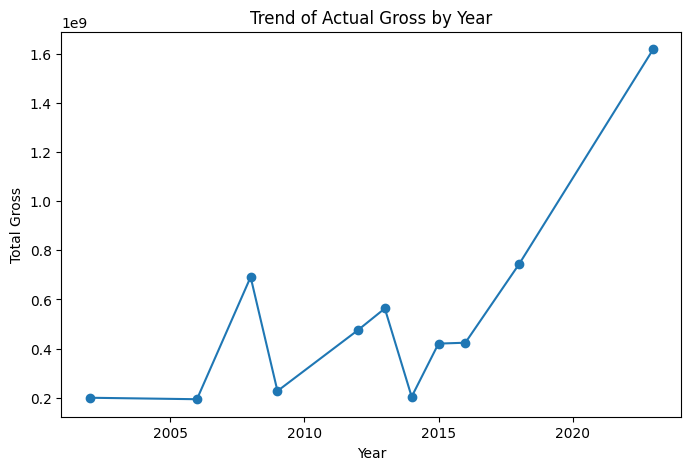

In [15]:
trend = df.groupby('Start Year')['Actual gross'].sum()

plt.figure(figsize=(8,5))
trend.plot(kind='line', marker='o')

plt.title("Trend of Actual Gross by Year")
plt.xlabel("Year")
plt.ylabel("Total Gross")
plt.show()